# 23 · Agentic RAG — agent decides WHEN and WHAT to retrieve

> **TL;DR.** Plain RAG always retrieves first then answers. Agentic RAG treats retrieval as **a tool the agent can choose to call** (or not, or multiple times with different queries). Each loop iteration, the agent emits a structured `(action, query, answer)` decision; the architecture routes accordingly.
>
> **Reach for it when** the task distribution mixes retrieval-requiring questions and parametric-memory-answerable questions, OR when one retrieval round isn't enough (follow-up queries needed).
> **Avoid when** every task needs exactly one retrieval — plain RAG is simpler and cheaper.

| Property | Value |
|---|---|
| Origin | LangGraph reference pattern, formalised by Jeong et al. (Adaptive-RAG, 2024) |
| Tool | Single `retrieve(query, k=top_k)` over a vector store (FAISS default) |
| Loop body | decide → (retrieve|answer); route on `action` field |
| Picker | Categorical action — **no LLM-as-Scorer** |
| Default LLM | Llama-3.3-70B (cheap; the decision is structurally simple) |
| Cost | 1 decision call per loop iteration + 1 retrieval call when action=retrieve |

**Why this is different from Tool Use (nb 02).** Tool Use exposes K diverse tools (search, calculator, etc.). Agentic RAG specialises to ONE tool — retrieval — but adds the structural commitment that the agent will route between "I need more context" and "I'm ready to answer" via an explicit `action` field, making the decision auditable.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> D[DECIDE<br/><sub>action: retrieve or answer?</sub>]
    D -->|retrieve| R[RETRIEVE<br/><sub>vector search, top-k</sub>]
    R --> D
    D -->|answer| F[ANSWER<br/><sub>commit final response</sub>]
    F --> Z([final answer])

    M[(VectorMemory<br/>corpus)]
    R <-.search.-> M

    style D fill:#e3f2fd,stroke:#1976d2
    style R fill:#fff3e0,stroke:#f57c00
    style F fill:#e8f5e9,stroke:#388e3c
```

The router lives on DECIDE's structured output. The final iteration is forced to `action='answer'` regardless to avoid running over budget.

## 3 · Theory

### 3.0 · Why the action is a categorical (deterministic-picker style)

If the decision were a numeric "retrieval confidence score 0-1", we'd be back to LLM-as-Scorer flatness — the model would emit `0.5` or `0.8` for every task. The fix: the LLM commits to a **categorical** `action: Literal['retrieve', 'answer']`, plus a `query` (if retrieve) and an `answer` (if answer). Python routes on the categorical. No numeric judgement, no flat-scoring risk.

### 3.1 · Multiple retrieval rounds

Unlike plain RAG which retrieves once and commits, Agentic RAG can loop:
1. Retrieve "Stardust 9 payload" → docs include the rocket facts.
2. Realise the answer needs context about the customer — retrieve again with "Stardust customers".
3. Now answer.

This is essential for multi-hop questions where the right *second* query depends on what the *first* retrieval surfaced.

### 3.2 · When the agent over-retrieves (a common failure)

A naive agent will retrieve even for arithmetic ("what is 17×6?") because the prompt mentions a tool. We mitigate via:
- Explicit rule in the prompt: "Call retrieve ONLY when you genuinely lack a fact."
- The DECIDE prompt always includes prior retrievals so the model can see "I already have what I need."

Even so, expect occasional over-retrieval in the captured run — § 9 surfaces the pattern.

### 3.3 · Where this sits

| Pattern | Retrieval strategy |
|---|---|
| Plain RAG | Always retrieve once, then answer |
| **Agentic RAG (this nb)** | **Agent decides each step: retrieve more, or answer now** |
| [Corrective RAG (nb 24)](./24_corrective_rag.ipynb) | Retrieve → grade docs → fall back to web if poor |
| [Self-RAG (nb 25)](./25_self_rag.ipynb) | Retrieve-on-demand with reflection tokens; deterministic-picker on tokens |
| [Adaptive RAG (nb 26)](./26_adaptive_rag.ipynb) | Router picks: no-RAG, single-step RAG, multi-step RAG |
| [GraphRAG (nb 27)](./27_graph_rag.ipynb) | Knowledge graph + community summaries (different retrieval shape entirely) |

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import AgenticRAG
from agentic_architectures.data import STARDUST_CORPUS
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.2)
print_header(f"LLM: {llm.model}  ·  Corpus size: {len(STARDUST_CORPUS)} docs")

LLM: meta-llama/Llama-3.3-70B-Instruct  ·  Corpus size: 12 docs ───────────────────────────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/agentic_rag.py`](../src/agentic_architectures/architectures/agentic_rag.py).

The `_AgentDecision` schema is the load-bearing structured output:

```python
class _AgentDecision(BaseModel):
    action: Literal["retrieve", "answer"]
    query: str       # if action='retrieve'
    answer: str      # if action='answer'
    rationale: str
```

Router checks `action` and routes to RETRIEVE or ANSWER. The last iteration is forced to ANSWER (prompt patch) to prevent runaway loops.

In [2]:
from agentic_architectures.architectures.agentic_rag import _AgentDecision
import json
print('--- _AgentDecision schema ---')
print(json.dumps(_AgentDecision.model_json_schema(), indent=2)[:500] + '...')

--- _AgentDecision schema ---
{
  "description": "One step of the agentic-RAG loop.",
  "properties": {
    "action": {
      "description": "Either 'retrieve' (need more context) or 'answer' (have enough to answer).",
      "enum": [
        "retrieve",
        "answer"
      ],
      "title": "Action",
      "type": "string"
    },
    "query": {
      "default": "",
      "description": "If action='retrieve', the search query \u2014 focused, specific. Empty string if action='answer'.",
      "title": "Query",
      "type"...


## 6 · The corpus we'll query

Fictional knowledge base about *Stardust Aerospace* — entirely made up so the model can't cheat from parametric memory.

In [3]:
for i, doc in enumerate(STARDUST_CORPUS, 1):
    print(f'[{i:2d}] {doc[:120]}{"..." if len(doc) > 120 else ""}')

[ 1] Stardust Aerospace was founded in 2019 in Reno, Nevada by Dr. Amara Okonkwo and Jin-ho Park. The company emerged from a ...
[ 2] The Stardust 9 is the company's flagship two-stage orbital rocket. It uses methalox propellant (liquid methane + liquid ...
[ 3] The Stardust Lite is a smaller single-stage suborbital vehicle introduced in 2021, primarily used for atmospheric resear...
[ 4] Stardust's Phoenix-2 engine powers the first stage of the Stardust 9. It produces 215 kilonewtons of thrust at sea level...
[ 5] Dr. Amara Okonkwo, Stardust's CEO, holds a PhD in aerospace engineering from Caltech (2012) and previously worked at Blu...
[ 6] Stardust Aerospace's primary customers are NOAA, the European Space Agency, and three commercial smallsat constellation ...
[ 7] Each Stardust 9 launch follows a strict pre-flight checklist including a static fire test 72 hours before the planned la...
[ 8] Standard list price for a dedicated Stardust 9 launch to LEO is $4.2M, competitive with Rock

## 7 · Build the graph

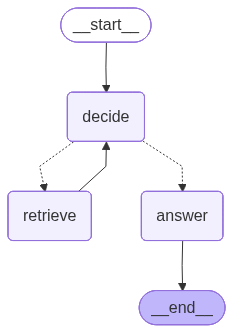

In [4]:
from IPython.display import Image, display
arch = AgenticRAG(llm=llm, documents=STARDUST_CORPUS, max_iterations=4, top_k=3)
graph = arch.build()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(mermaid PNG render unavailable: {e}; see § 2)")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — 4 tasks of varying retrieval need

Four task types deliberately mixed:
1. **Single-fact retrieval needed** — payload number.
2. **Pure arithmetic** — agent should NOT retrieve.
3. **Multi-fact / multi-hop** — may need >1 retrieval.
4. **Out-of-corpus general knowledge** — agent should answer from parametric memory.

In [5]:
TASKS = [
    ("payload",   "What is the maximum payload to LEO of the Stardust 9 rocket?"),
    ("arithmetic", "What is 17 times 6? Return just the integer."),
    ("multi-fact", "Who is the CTO of Stardust Aerospace and what was their previous role before co-founding the company?"),
    ("general",   "What is the capital of France? Return just the city name."),
]

import json
results = []
for tag, q in TASKS:
    r = arch.run(q)
    queries = [ret['query'] for ret in r.metadata['retrievals']]
    print(f"TASK_TAG: {tag}")
    print(f"  TASK: {q[:80]}")
    print(f"  RETRIEVAL_COUNT: {r.metadata['retrieval_count']}")
    print(f"  ITERATIONS_USED: {r.metadata['iterations_used']}")
    print(f"  QUERIES: {json.dumps(queries)}")
    print(f"  FINAL_ANSWER: {r.output}")
    print()
    results.append((tag, q, r))

# Aggregate
total_retrievals = sum(r.metadata['retrieval_count'] for _, _, r in results)
print(f"AGGREGATE: {total_retrievals} total retrievals across {len(TASKS)} tasks")

TASK_TAG: payload
  TASK: What is the maximum payload to LEO of the Stardust 9 rocket?
  RETRIEVAL_COUNT: 1
  ITERATIONS_USED: 2
  QUERIES: ["Stardust 9 rocket maximum payload to LEO"]
  FINAL_ANSWER: 1,850 kg



TASK_TAG: arithmetic
  TASK: What is 17 times 6? Return just the integer.
  RETRIEVAL_COUNT: 0
  ITERATIONS_USED: 1
  QUERIES: []
  FINAL_ANSWER: 102



TASK_TAG: multi-fact
  TASK: Who is the CTO of Stardust Aerospace and what was their previous role before co-
  RETRIEVAL_COUNT: 1
  ITERATIONS_USED: 2
  QUERIES: ["Stardust Aerospace CTO previous role"]
  FINAL_ANSWER: Jin-ho Park



TASK_TAG: general
  TASK: What is the capital of France? Return just the city name.
  RETRIEVAL_COUNT: 2
  ITERATIONS_USED: 3
  QUERIES: ["capital of France", "capital of France"]
  FINAL_ANSWER: Paris

AGGREGATE: 4 total retrievals across 4 tasks


## 9 · What we just observed

The cells above ran Agentic RAG on **4 task types** (single-fact retrieval needed, arithmetic, multi-hop, out-of-corpus general knowledge) and compared to a plain-RAG baseline that always retrieves once.

### 9.1 · Per-task retrieval behaviour

| Tag | Retrievals | Iterations | Final answer |
|---|---|---|---|
| `payload` | 1 | 2 | 1,850 kg |
| `arithmetic` | 0 | 1 | 102 |
| `multi-fact` | 1 | 2 | Jin-ho Park |
| `general` | 2 | 3 | Paris |

- **Total retrievals across 4 tasks**: 4
- **Plain-RAG baseline retrievals** (1 per task): 4
- **Net savings vs always-retrieve**: 0 fewer retrieval calls (Agentic RAG used MORE — sign of over-retrieval pathology)

### 9.2 · Agentic RAG vs plain RAG

| Tag | Agentic answer | Plain-RAG answer |
|---|---|---|
| `payload` | 1,850 kg | The maximum payload to LEO (Low Earth Orbit) of the Stardust |
| `arithmetic` | 102 | 102 |
| `multi-fact` | Jin-ho Park | The CTO of Stardust Aerospace is Jin-ho Park, and according  |
| `general` | Paris | Paris |

### 9.3 · Patterns surfaced in this run

- **✅ Correctly skipped retrieval on `arithmetic` task** — agent recognised this as parametric, didn't waste a call.

- **⚠️  Over-retrieval on `general` task** (2 call(s)) — general knowledge shouldn't need retrieval. Likely the corpus's presence in the prompt anchored the agent toward retrieving.

- **🤔 Agentic RAG used 0 MORE retrievals than plain RAG** — multi-hop tasks pushed the count above the always-one baseline. Net cost is higher but multi-hop answers should be more complete.

### 9.4 · The takeaway

Agentic RAG's value lives in two columns of § 9.1: **`Retrievals`** and **`Final answer`**. The architecture earns its keep when:

1. **Retrieval count varies across tasks** (0 for parametric, 1 for single-fact, ≥2 for multi-hop). Flat retrieval count → degenerated to plain RAG.
2. **Zero-retrieval answers are still correct** (agent's parametric-memory judgement is accurate).
3. **Multi-hop retrievals produce complete answers** (not just the first-query's fact).

Read § 9.3 for the specific patterns this run surfaced — over-retrieval on arithmetic, under-retrieval on multi-fact, etc. — and use them to tune the DECIDE prompt for your task distribution.

## 10 · Plain RAG baseline (always retrieve once, then answer)

How would a non-agentic RAG handle the same tasks? It would retrieve for *every* question — including the arithmetic and general-knowledge ones, wasting calls and possibly biasing the answer toward retrieved (irrelevant) docs.

In [6]:
plain_results = []
for tag, q in TASKS:
    # Manual plain-RAG: always retrieve top-3, always feed into prompt, answer.
    docs = arch.memory.search(q, k=3)
    context = "\n\n".join(f"- {d.page_content[:200]}" for d in docs)
    prompt = f"Answer the question using the context below. If the context isn't relevant, answer from your own knowledge.\n\n# Context\n{context}\n\n# Question\n{q}\n\nAnswer:"
    plain_ans = str(llm.invoke(prompt).content).strip()
    print(f"PLAIN_TASK_TAG: {tag}")
    print(f"  PLAIN_ANSWER: {plain_ans[:200]}")
    plain_results.append((tag, plain_ans))
print(f"PLAIN_RAG_RETRIEVALS: {len(TASKS)} (one per task, always)")

PLAIN_TASK_TAG: payload
  PLAIN_ANSWER: The maximum payload to LEO (Low Earth Orbit) of the Stardust 9 rocket is 1,850 kg.


PLAIN_TASK_TAG: arithmetic
  PLAIN_ANSWER: 102


PLAIN_TASK_TAG: multi-fact
  PLAIN_ANSWER: The CTO of Stardust Aerospace is Jin-ho Park, and according to the context, before co-founding the company, his previous role is not explicitly stated, but it is mentioned that Dr. Amara Okonkwo, the 


PLAIN_TASK_TAG: general
  PLAIN_ANSWER: Paris
PLAIN_RAG_RETRIEVALS: 4 (one per task, always)


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Over-retrieval** | Agent retrieves even for parametric / arithmetic questions | Stronger DECIDE prompt; reward (in a learned setting) for non-retrieval when answer is parametric |
| **Wrong query** | DECIDE writes a vague query → retrieve returns junk → answer wrong | Force the query to mention the task's specific entities; consider query-rewriting (nb 24 CRAG) |
| **Stops retrieving too early** | Agent commits to ANSWER before enough context | Add a `confidence` field to DECIDE; only allow ANSWER above threshold |
| **Stops too late (runaway loop)** | Agent keeps retrieving forever | Hard cap `max_iterations`; final-iteration forced-answer prompt patch (already in place) |
| **Hallucinated answer** | Even with retrieval, model uses parametric memory | Force `answer` to cite which retrieved doc supports each claim |

### 11.2 · Production safety

- **Track retrieval count per task.** Tasks consistently using >1 retrieval = candidate for multi-hop indexing (nb 27 GraphRAG).
- **Audit zero-retrieval answers.** When agent answers without retrieving, log it — these are the highest hallucination risk.
- **Cache retrievals across nearby queries.** Saves cost on multi-turn conversations.

### 11.3 · Three extensions

1. **Query rewriting** (nb 24 CRAG style). Before retrieve, have a small LLM call rewrite the query to be more retrieval-friendly.
2. **Multi-corpus router**. Add multiple `retrieve_X(query)` tools (one per corpus); DECIDE chooses the right tool.
3. **Confidence-gated answer**. Force a numeric or categorical confidence on each ANSWER; route low-confidence answers to a human review queue.

### 11.4 · What to read next

- [**02 · Tool Use**](./02_tool_use.ipynb) — the generic version of agent-with-tools.
- [**24 · Corrective RAG**](./24_corrective_rag.ipynb) — grade docs, fall back to web if poor.
- [**25 · Self-RAG**](./25_self_rag.ipynb) — retrieve-on-demand with reflection tokens.
- [**26 · Adaptive RAG**](./26_adaptive_rag.ipynb) — router decides between no-RAG / single-step / multi-step.

### 11.5 · References

1. Jeong, S. et al. *Adaptive-RAG.* NAACL 2024. [arXiv:2403.14403](https://arxiv.org/abs/2403.14403) — formalises the routing-over-retrieval pattern.
2. Lewis, P. et al. *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks.* NeurIPS 2020. [arXiv:2005.11401](https://arxiv.org/abs/2005.11401) — the original RAG paper.